© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

# EoMT Project: Cross-Domain Inference on Cityscapes and COCO

This notebook explores the **Everything on My Terms (EoMT)** framework, powered by the **DinoV2** backbone.
The objective is to analyze and compare two different deep learning approaches:
1. **Domain-Specific Semantic Segmentation:** Trained on Cityscapes for autonomous driving.
2. **General-Purpose Panoptic Segmentation:** Trained on the COCO dataset to identify individual object instances.

## Setup Import


In [1]:
import yaml
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
from huggingface_hub import hf_hub_download
from huggingface_hub.utils import RepositoryNotFoundError
import warnings
import importlib
from lightning import seed_everything
from tqdm import tqdm

# Cityscapes Specialist Model (Semantic)
In this section, we load the model specifically trained fro urban environments. This model performs **Semantic Segmentation**, where pixels are categorized into classes (road, car, sidewalk) without distinguishing between individual objects of the same class.

In [2]:
seed_everything(0, verbose=False)

device = 0  # change to the GPU you want to use
img_idx = 0  # change to the index of the image you want to visualize
config_path = "./configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"  # change to the config file
data_path = "../Cityscapes"  # change to the dataset directory

with open(config_path, "r") as f:
    config = yaml.safe_load(f)


def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [3]:
data_module_name, class_name = config["data"]["class_path"].rsplit(".", 1)
data_module = getattr(importlib.import_module(data_module_name), class_name)
data_module_kwargs = config["data"].get("init_args", {})

data = data_module(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_module_kwargs
).setup()

## Load model

In [4]:
warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

# Load encoder
encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
encoder = encoder_cls(img_size=data.img_size, **encoder_cfg.get("init_args", {}))

# Load network
network_cfg = config["model"]["init_args"]["network"]
network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}
network = network_cls(
    masked_attn_enabled=False,
    num_classes=data.num_classes,
    encoder=encoder,
    **network_kwargs,
)

# Load Lightning module
lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}
if "stuff_classes" in config["data"].get("init_args", {}):
    model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

model = (
    lit_cls(
        img_size=data.img_size,
        num_classes=data.num_classes,
        network=network,
        **model_kwargs,
    )
    .eval()
    .to(device)
)

## Load pre-trained weights from Hugging Face Hub
The model weights are downloaded from the Hugging Face Hub using the logger name from the config. Make sure you have a working internet connection.

In [5]:
name = config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name")
hugging_face_repo="gruppofundamentals1"
if name is None:
    warnings.warn("No logger name found in the config. Please specify a model name.")
else:
    try:
        state_dict_path = hf_hub_download(
            repo_id=f"{hugging_face_repo}/{name}", #change to the Hugging Face Hub repo name
            filename="pytorch_model.bin",
        )

        is_dinov3 = "dinov3" in name

        if is_dinov3:
            model_kwargs["ckpt_path"] = state_dict_path
            model_kwargs["delta_weights"] = True

        model = (
            lit_cls(
                img_size=data.img_size,
                num_classes=data.num_classes,
                network=network,
                **model_kwargs,
            )
            .eval()
            .to(device)
        )

        if not is_dinov3:
            state_dict = torch.load(
                state_dict_path, map_location=f"cuda:{device}", weights_only=True
            )
            model.load_state_dict(state_dict, strict=False)

    except RepositoryNotFoundError:
        warnings.warn(
            f"Pre-trained model not found for `{name}`. Please load your own checkpoint."
        )

## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

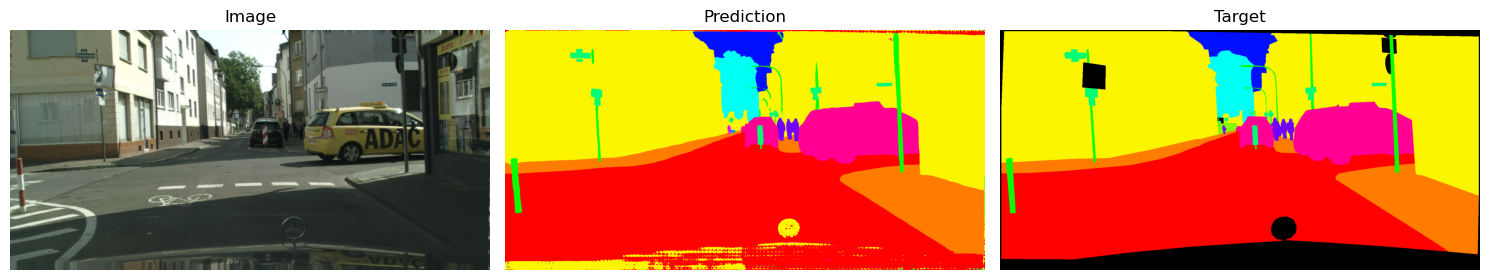

In [6]:
IGNORE_INDEX = 255


def infer_semantic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]
        crops, origins = model.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model(crops)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data.img_size, mode="bilinear"
        )

        crop_logits = model.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]
pred_array, target_array = infer_semantic(img, target)
plot_semantic_results(img, pred_array, target_array)

## Panoptic inference (segmentation with instance IDs)

> This inference method also works when applied to a model trained for instance segmentation.

Panoptic inference assigns each pixel $[h, w]$ to the query $i$ that maximizes the product of class and mask confidence:

$$
p_i(c_i) \cdot m_i[h, w]
$$

where $c_i = \arg\max_c \, p_i(c)$ is the most likely class for query $i$. A pixel is assigned to a query only if both the class confidence and mask confidence are high. Pixels assigned to the same query form a segment labeled with $c_i$. "Stuff" segments with the same class are merged; "thing" segments are kept distinct using the query index. Low-confidence and heavily occluded predictions are filtered out.  
  
*This inference method was originally introduced in MaskFormer.*

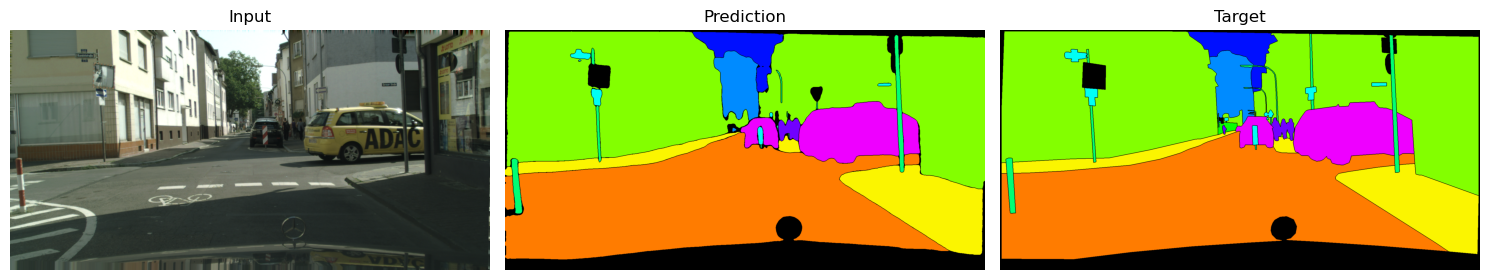

In [7]:
def infer_panoptic(img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model.img_size, mode="bilinear"
        )
        mask_logits = model.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model.stuff_classes,
            model.mask_thresh,
            model.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    target_seg = model.to_per_pixel_targets_panoptic([target])[0].cpu().numpy()
    sem_target, inst_target = target_seg[..., 0], target_seg[..., 1]

    return sem_pred, inst_pred, sem_target, inst_target


def draw_black_border(sem, inst, mapping):
    h, w = sem.shape
    out = np.zeros((h, w, 3))
    for s in np.unique(sem):
        out[sem == s] = mapping[s]

    combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    out[border] = 0
    return out


def plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target):
    all_ids = np.union1d(np.unique(sem_pred), np.unique(sem_target))
    mapping = {
        s: (
            [0, 0, 0]
            if s == -1 or s == model.num_classes
            else plt.cm.hsv(i / len(all_ids))[:3]
        )
        for i, s in enumerate(all_ids)
    }

    vis_pred = draw_black_border(sem_pred, inst_pred, mapping)
    vis_target = draw_black_border(sem_target, inst_target, mapping)

    img_np = (
        img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title("Prediction")
    axes[2].imshow(vis_target)
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data.val_dataloader().dataset[img_idx]
sem_pred, inst_pred, sem_target, inst_target = infer_panoptic(img, target)
plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target)

## Login in the Hugging Face Account
it is where the original checkpoints are saved

In [8]:
from huggingface_hub import login
login()

## Stup and loading  Coco model 

In [9]:
# 1. CONFIGURATION WEIGHTS
config_path_coco = "./configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml" # Change the configuration path for coco

with open(config_path_coco, "r") as f:
    config_coco = yaml.safe_load(f)

# 2. ENCODER INITIALIZATION COCO
encoder_cfg_coco = config_coco["model"]["init_args"]["network"]["init_args"]["encoder"]
encoder_module_name_coco, encoder_class_name_coco = encoder_cfg_coco["class_path"].rsplit(".", 1)
encoder_cls_coco = getattr(importlib.import_module(encoder_module_name_coco), encoder_class_name_coco)

encoder_coco = encoder_cls_coco(img_size=(640,640), **encoder_cfg_coco.get("init_args", {}))

# 3. NETWORK INITIALIZATION COCO
network_cfg_coco = config_coco["model"]["init_args"]["network"]
network_module_name_coco, network_class_name_coco = network_cfg_coco["class_path"].rsplit(".", 1)
network_cls_coco = getattr(importlib.import_module(network_module_name_coco), network_class_name_coco)
network_kwargs_coco = {k: v for k, v in network_cfg_coco["init_args"].items() if k != "encoder"}

num_classes_coco = 133 # Standard classes COCO Panoptic

network_coco = network_cls_coco(
    masked_attn_enabled=False,
    num_classes=num_classes_coco,
    encoder=encoder_coco,
    **network_kwargs_coco,
)

# 4. LIGHTNING MODULE
lit_module_name_coco, lit_class_name_coco = config_coco["model"]["class_path"].rsplit(".", 1)
lit_cls_coco = getattr(importlib.import_module(lit_module_name_coco), lit_class_name_coco)
model_kwargs_coco = {k: v for k, v in config_coco["model"]["init_args"].items() if k != "network"}

# 'stuff_classes' from config COCO
model_kwargs_coco["stuff_classes"] = config_coco["model"]["init_args"].get("stuff_classes", list(range(80, 133)))

model_coco = (
    lit_cls_coco(
        img_size=(640, 640),
        num_classes=num_classes_coco,
        network=network_coco,
        **model_kwargs_coco,
    )
    .eval()
    .to(device)
)

# 5. DOWNLOAD AND WEIGHTS UPLOAD
img_size_coco = (640, 640)
name_coco = config_coco.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name")

try:
    print(f"Download weights for {name_coco}...")
    state_dict_path_coco = hf_hub_download(repo_id=f"{hugging_face_repo}/{name_coco}", filename="pytorch_model.bin")
    state_dict_coco = torch.load(state_dict_path_coco, map_location=f"cuda:{device}", weights_only=True)

    model_coco.load_state_dict(state_dict_coco, strict=False)
    print("✅ COCO Panoptic model loaded")
except Exception as e:
    print(f"❌ Error during loading: {e}")

def infer_panoptic_coco(img, target):
    with torch.no_grad(), torch.amp.autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model_coco.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_coco(transformed_imgs)

        mask_logits = torch.nn.functional.interpolate(
            mask_logits_per_layer[-1], model_coco.img_size, mode="bilinear"
        )
        mask_logits = model_coco.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model_coco.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model_coco.stuff_classes,
            model_coco.mask_thresh,
            model_coco.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    return pred[..., 0], pred[..., 1] # sem_pred, inst_pred



Download weights for coco_panoptic_eomt_base_640...
✅ COCO Panoptic model loaded


## Qualitative comparison between Cityscapes and Coco predictions

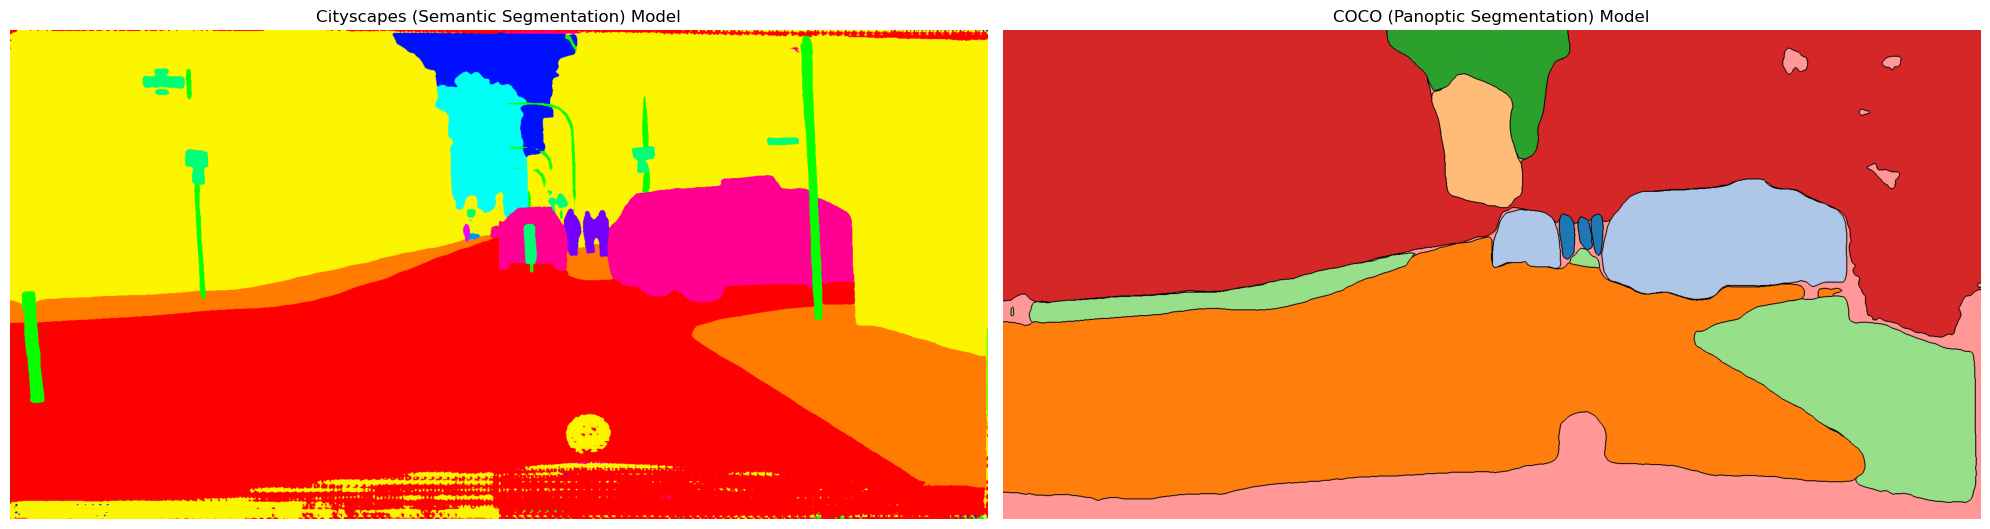

In [10]:
# Imagine from Cityscapes
img, target = data.val_dataloader().dataset[img_idx]

# 1. Prediction Cityscapes (Semantic)
pred_sem_cs, _ = infer_semantic(img, target)

# 2. Prediction COCO (Panoptic)
sem_pred_coco, inst_pred_coco = infer_panoptic_coco(img, target)

# 3. Visualization
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Color map for Cityscapes
mapping_cs = create_mapping([pred_sem_cs], IGNORE_INDEX)
axes[0].imshow(apply_colormap(pred_sem_cs, mapping_cs))
axes[0].set_title("Cityscapes (Semantic Segmentation) Model")
axes[0].axis('off')

# Color map for Coco
all_ids = np.unique(sem_pred_coco)
mapping_coco = {s: plt.cm.tab20(i % 20)[:3] for i, s in enumerate(all_ids)}
vis_coco = draw_black_border(sem_pred_coco, inst_pred_coco, mapping_coco)
axes[1].imshow(vis_coco)
axes[1].set_title("COCO (Panoptic Segmentation) Model")
axes[1].axis('off')

plt.tight_layout()
plt.show()

## MAPPING

# Quantitative Evaluation — mIoU on Cityscapes Validation Set


Both models are evaluated on the 19 Cityscapes train classes using the
Cityscapes ground truth. The Cityscapes model predicts directly in that space.
The COCO panoptic model predicts in its own contiguous 0-132 class space
(defined by CLASS_MAPPING in coco_panoptic.py), which we map to the 19
Cityscapes classes before computing metrics. Unmapped classes → ignore (255).
This ensures a single, identical evaluation pipeline for both models.

In [11]:
CITYSCAPES_IGNORE = 255
NUM_CS_CLASSES = 19

CS_CLASS_NAMES = [
    "road", "sidewalk", "building", "wall", "fence", "pole",
    "traffic light", "traffic sign", "vegetation", "terrain",
    "sky", "person", "rider", "car", "truck", "bus",
    "train", "motorcycle", "bicycle"
]

"""
COCO Panoptic CONTIGUOUS IDs (0-132) → Class names

THINGS (0-79)
0:   person
1:   bicycle
2:   car
3:   motorcycle
4:   airplane
5:   bus
6:   train
7:   truck
8:   boat
9:   traffic light
10:  fire hydrant
11:  stop sign
12:  parking meter
13:  bench
14:  bird
15:  cat
16:  dog
17:  horse
18:  sheep
19:  cow
20:  elephant
21:  bear
22:  zebra
23:  giraffe
24:  backpack
25:  umbrella
26:  handbag
27:  tie
28:  suitcase
29:  frisbee
30:  skis
31:  snowboard
32:  sports ball
33:  kite
34:  baseball bat
35:  baseball glove
36:  skateboard
37:  surfboard
38:  tennis racket
39:  bottle
40:  wine glass
41:  cup
42:  fork
43:  knife
44:  spoon
45:  bowl
46:  banana
47:  apple
48:  sandwich
49:  orange
50:  broccoli
51:  carrot
52:  hot dog
53:  pizza
54:  donut
55:  cake
56:  chair
57:  couch
58:  potted plant
59:  bed
60:  dining table
61:  toilet
62:  tv
63:  laptop
64:  mouse
65:  remote
66:  keyboard
67:  cell phone
68:  microwave
69:  oven
70:  toaster
71:  sink
72:  refrigerator
73:  book
74:  clock
75:  vase
76:  scissors
77:  teddy bear
78:  hair drier
79:  toothbrush


STUFF (80-132)
80:  banner
81:  blanket
82:  branch
83:  bridge
84:  building-other
85:  cloud
86:  door-stuff
87:  floor-wood
88:  flower
89:  fruit
90:  gravel
91:  house
92:  light
93:  mirror-stuff
94:  net
95:  pillow
96:  platform
97:  playingfield
98:  railroad
99:  river
100: road
101: roof
102: sand
103: sea
104: shelf
105: snow
106: stair
107: tent
108: towel
109: wall-brick
110: wall-stone
111: wall-tile
112: wall-wood
113: water-other
114: window-blind
115: window-other
116: tree
117: fence
118: ceiling-other
119: sky
120: cab
121: parking
122: mountain
123: pavement
124: grass
125: dirt
126: paper
127: food-other
128: building
129: rock
130: wall
131: rug
132: floor-other

"""
# Start with all ignored
_lut = np.full(134, CITYSCAPES_IGNORE, dtype=np.int64)

# THINGS NOT IGNORED
_lut[0]  = 11   # person -> person
_lut[1]  = 18   # bicycle -> bicycle
_lut[2]  = 13   # car -> car
_lut[3]  = 17   # motorcycle -> motorcycle
_lut[5]  = 15   # bus -> bus
_lut[6]  = 16   # train -> train
_lut[7]  = 14   # truck -> truck
_lut[9]  = 6    # traffic light -> traffic light
_lut[11] = 7    # stop sign -> traffic sign


# STUFF NOT IGNORED
_lut[90]  = 9   # gravel -> terrain
_lut[91]  = 2   # house -> building
_lut[100] = 0   # road
_lut[101] = 2   # roof -> building
_lut[102] = 9   # sand -> terrain

_lut[109] = 3   # wall-brick -> wall
_lut[110] = 3   # wall-stone -> wall
_lut[111] = 3   # wall-tile -> wall
_lut[112] = 3   # wall-wood -> wall

_lut[116] = 8 # tree -> vegetation
_lut[117] = 4 # fence
_lut[119] = 10 # sky

_lut[123] = 1 # pavement -> sidewalk
_lut[124] = 9 # mountain -> terrain
_lut[125] = 8 # grass -> vegetation
_lut[129] = 2 # building
_lut[131] = 3 # wall

def map_coco_to_cityscapes(sem_pred_coco: np.ndarray) -> np.ndarray:
    """Map COCO panoptic contiguous IDs (0-132) → Cityscapes train IDs (0-18).
    Pixels with class == num_classes (133, i.e. 'no object') → ignore.
    """
    out = np.full_like(sem_pred_coco, CITYSCAPES_IGNORE, dtype=np.int64)
    valid = (sem_pred_coco >= 0) & (sem_pred_coco < 133)
    out[valid] = _lut[sem_pred_coco[valid]]
    return out


# Shared mIoU computation via confusion matrix
def compute_confusion_matrix(pred, target, num_classes, ignore_index):
    mask = target != ignore_index
    p = pred[mask].astype(np.int64)
    t = target[mask].astype(np.int64)
    valid = (p >= 0) & (p < num_classes)
    p, t = p[valid], t[valid]
    return np.bincount(num_classes * t + p,
                       minlength=num_classes ** 2).reshape(num_classes, num_classes)

def miou_from_cm(cm):
    inter = np.diag(cm)
    union = cm.sum(1) + cm.sum(0) - inter
    iou = np.where(union > 0, inter / union, np.nan)
    return float(np.nanmean(iou)), iou

In [12]:
# Evaluation loop
val_dataset = data.val_dataloader().dataset
print(f"Validation images: {len(val_dataset)}")

cm_cs   = np.zeros((NUM_CS_CLASSES, NUM_CS_CLASSES), dtype=np.int64)
cm_coco = np.zeros((NUM_CS_CLASSES, NUM_CS_CLASSES), dtype=np.int64)

for idx in tqdm(range(len(val_dataset)), desc="Evaluating"):
    img, target = val_dataset[idx]

    # Cityscapes model → already in 0-18 space
    pred_cs, target_cs = infer_semantic(img, target)
    cm_cs += compute_confusion_matrix(pred_cs, target_cs, NUM_CS_CLASSES, CITYSCAPES_IGNORE)

    # COCO model → map contiguous 0-132 → Cityscapes 0-18
    # Same Cityscapes ground truth (target_cs) is used for fair comparison
    sem_pred_coco, _ = infer_panoptic_coco(img, target)
    pred_coco_mapped = map_coco_to_cityscapes(sem_pred_coco)
    cm_coco += compute_confusion_matrix(pred_coco_mapped, target_cs, NUM_CS_CLASSES, CITYSCAPES_IGNORE)

# Results table
miou_cs,   iou_cs   = miou_from_cm(cm_cs)
miou_coco, iou_coco = miou_from_cm(cm_coco)

print(f"\n{'Class':<22} {'Cityscapes':>12} {'COCO':>10}")
print("─" * 46)
for i, name in enumerate(CS_CLASS_NAMES):
    v_cs   = f"{iou_cs[i]*100:5.1f}%"   if not np.isnan(iou_cs[i])   else "   N/A"
    v_coco = f"{iou_coco[i]*100:5.1f}%" if not np.isnan(iou_coco[i]) else "   N/A"
    print(f"{name:<22} {v_cs:>12} {v_coco:>10}")
print("─" * 46)
print(f"{'mIoU':<22} {miou_cs*100:>11.1f}% {miou_coco*100:>9.1f}%")

Validation images: 500


Evaluating: 100%|██████████| 500/500 [17:58<00:00,  2.16s/it]


Class                    Cityscapes       COCO
──────────────────────────────────────────────
road                          98.4%      94.4%
sidewalk                      87.4%      64.6%
building                      94.1%      86.7%
wall                          66.1%      51.6%
fence                         65.5%      47.4%
pole                          71.0%       0.0%
traffic light                 75.0%      45.1%
traffic sign                  82.1%       1.8%
vegetation                    93.0%      85.0%
terrain                       66.6%       0.0%
sky                           95.5%      88.6%
person                        85.4%      68.1%
rider                         71.1%       0.0%
car                           95.5%      84.2%
truck                         81.8%      30.4%
bus                           90.3%      69.2%
train                         77.4%       0.0%
motorcycle                    74.4%      65.7%
bicycle                       81.3%      68.6%
────────────

# Step 5 — Fine-tuning EoMT (COCO panoptic ➜ Cityscapes semantic)

**Objective:** Adapt the EoMT checkpoint pretrained on COCO Panoptic (133 classes, 200 queries) to the Cityscapes semantic segmentation task (19 classes, 100 queries), and compare its performance against the repository-provided Cityscapes-pretrained model.

**Strategy (T4, Colab Free):**
1. Reuse the repository's `MaskClassificationSemantic` module, which already provides Hungarian matching loss, automatic mixed precision (AMP), and learning-rate scheduling.
2. Load the COCO-pretrained checkpoint while discarding the incompatible `class_head` (134 → 20 outputs) and `q.weight` (200 → 100 queries); both components are randomly reinitialized.
3. **Phase A (head warm-up, ~1 epoch):** freeze the DINOv2 backbone and train only the task-specific layers (`q`, `class_head`, `mask_head`, and `upscale`).
4. **Phase B (joint fine-tuning, ~15–25 epochs):** unfreeze the backbone and continue training with a significantly lower learning rate for backbone parameters (1e-5) than for the task-specific heads (1e-4).
5. Use AMP (`precision="16-mixed"`), `batch_size=2`, `img_size=(640, 640)`, and `gradient_clip_val=0.01` to fit within Colab Free GPU memory constraints.
6. Save periodic checkpoints together with the best-performing checkpoint according to validation mIoU.


## Imports and Path configuration

- `data_path`: path with datasets `leftImg8bit_trainvaltest.zip` and `gtFine_trainvaltest.zip`.
- `coco_ckpt_path`: COCO's checkpoint COCO saved at the end of step 4 (`coco_pretrained_checkpoint.pt`).
- `ft_out_dir`: where to save new checkpoints.

In [1]:
import os
from pathlib import Path
from datasets.cityscapes_semantic import CityscapesSemantic
from models.eomt import EoMT
from models.vit import ViT
from training.mask_classification_semantic import MaskClassificationSemantic
from training.mask_classification_loss import MaskClassificationLoss
from torch.optim import AdamW
import lightning as L
from lightning.pytorch.loggers import WandbLogger
import types
from peft import LoraConfig, get_peft_model
import torch

DATA_PATH      = "../Cityscapes"                                    # Change the data path
COCO_CKPT      = "./checkpoints/coco_pretrained_checkpoint.pt"      # Change the path of coco_checkpoint
FT_OUT_DIR     = "./checkpoints"  # Change the output directory
os.makedirs(FT_OUT_DIR, exist_ok=True)

IMG_SIZE       = (640, 640)
NUM_CLASSES    = 19           # Cityscapes train classes
NUM_QUERIES    = 100          # as in config Cityscapes
NUM_BLOCKS     = 3            # as in config
BATCH_SIZE     = 2            
NUM_WORKERS    = 2
MAX_EPOCHS = 15

# Save pretrained coco_checpoints from step 4
if not Path(COCO_CKPT).exists():
    torch.save(model_coco.state_dict(), COCO_CKPT)
    print(f"✅ Checkpoint saved {COCO_CKPT}")
else:
    print(f"ℹ️ Checkpoint already saved: {COCO_CKPT}")

print('Output  :', FT_OUT_DIR)

ℹ️ Checkpoint already saved: ./checkpoints/coco_pretrained_checkpoint.pt
Output  : ./checkpoints


## DataModule and Model Construction

The repository implementations are used directly. **Note:** the COCO checkpoint is not passed through the LightningModule `ckpt_path` argument because a custom loading procedure is required. Specifically, the pretrained `class_head` (134 → 20 outputs) and `q.weight` (200 → 100 queries) are incompatible with the Cityscapes configuration and must therefore be excluded from the checkpoint before loading. 

The repository code already handles the exclusion of `class_head` parameters, but not the query embeddings. For this reason, the checkpoint is filtered manually and the incompatible layers are randomly reinitialized.

In [2]:
# DataModule
data = CityscapesSemantic(
    path=DATA_PATH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    color_jitter_enabled=True,
    scale_range=(0.5, 2.0),
    check_empty_targets=True,
).setup()
print('Train size:', len(data.cityscapes_train_dataset), '| Val size:', len(data.cityscapes_val_dataset))

# Network: encoder DINOv2 base patch14 reg4 + EoMT head
encoder = ViT(
    img_size=IMG_SIZE,
    backbone_name='vit_base_patch14_reg4_dinov2',
)
network = EoMT(
    encoder=encoder,
    num_classes=NUM_CLASSES,
    num_q=NUM_QUERIES,
    num_blocks=NUM_BLOCKS,
    masked_attn_enabled=True,
)

# LightningModule (loss + train_step + eval_step)
model = MaskClassificationSemantic(
    network=network,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    attn_mask_annealing_enabled=True,
    attn_mask_annealing_start_steps=[3317, 8292, 13268],
    attn_mask_annealing_end_steps=  [6634,11609,16585],
    lr=1e-4,                # base lr
    llrd=1.0,               # no layer-wise decay: handled with freeze
    weight_decay=0.05,
    poly_power=0.9,
    warmup_steps=[100, 200],
    no_object_coefficient=0.1,
    mask_coefficient=5.0,
    dice_coefficient=5.0,
    class_coefficient=2.0,
)
print('Model OK – params:', sum(p.numel() for p in model.parameters())/1e6, 'M')

Train size: 2975 | Val size: 500
Model OK – params: 93.498644 M


c:\Users\user\anaconda3\envs\pytorch_gpu\Lib\site-packages\lightning\pytorch\utilities\parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.


## Loading the COCO Checkpoint with Custom Filtering

**Step 4 produces the `model_coco.state_dict()` of the LightningModule**, containing keys such as `network.encoder.backbone.*`, `network.q.weight`, `network.class_head.*`, `network.mask_head.*`, `network.upscale.*`, `criterion.empty_weight`, and metric-related buffers.

The following parameters are discarded before loading:

- `class_head.*` (134 outputs in COCO vs 20 in Cityscapes)
- `q.weight` (200 queries vs 100 queries)
- `criterion.empty_weight` (different size due to the different number of classes)
- metric-related states and buffers from TorchMetrics

The following parameters are retained:

- the entire ViT encoder (DINOv2 pretrained and further adapted on COCO)
- `mask_head`
- `upscale`

These are the components that carry the useful knowledge learned during COCO pretraining and are therefore transferred to the Cityscapes model.

In [5]:
raw = torch.load(COCO_CKPT, map_location='cpu', weights_only=False)
ckpt = raw['state_dict'] if isinstance(raw, dict) and 'state_dict' in raw else raw
ckpt = {k.replace('._orig_mod', ''): v for k, v in ckpt.items()}
print('Total keys in ckpt:', len(ckpt))

model_keys = set(model.state_dict().keys())

def keep(k, v):
    if 'class_head' in k or 'class_predictor' in k:    # mismatch 134 vs 20
        return False
    if k == 'network.q.weight':                        # mismatch 200 vs 100
        return False
    if 'criterion.empty_weight' in k:                  # rebuild from scratch
        return False
    if 'metrics.' in k:                                # torchmetrics buffers
        return False
    if k not in model_keys:
        return False
    if model.state_dict()[k].shape != v.shape:         # safety net on shape
        print(f'  skip shape-mismatch: {k}  {tuple(v.shape)} vs {tuple(model.state_dict()[k].shape)}')
        return False
    return True

filtered = {k: v for k, v in ckpt.items() if keep(k, v)}
print(f'Loadable: {len(filtered)} / {len(ckpt)}')

missing, unexpected = model.load_state_dict(filtered, strict=False)
# "missing" should be only: q.weight, class_head.*, criterion.empty_weight, attn_mask_probs, metrics.*
expected_missing = {'network.q.weight'}
for k in list(missing):
    if any(s in k for s in ['class_head','criterion.empty_weight','attn_mask_probs','metrics.']):
        expected_missing.add(k)
unexpected_missing = [k for k in missing if k not in expected_missing]
print('Missing expected (ok, reinit random):', sorted(expected_missing))
if unexpected_missing:
    print('⚠️  Missing unexpected:', unexpected_missing)
if unexpected:
    print('⚠️  Unexpected:', unexpected)

torch.nn.init.normal_(model.network.q.weight, std=0.02)
print('✅ ckpt COCO uploaded (head + query reinitializated for 19 classes)')

Total keys in ckpt: 198
Loadable: 194 / 198
Missing expected (ok, reinit random): ['criterion.empty_weight', 'network.class_head.bias', 'network.class_head.weight', 'network.q.weight']
✅ ckpt COCO uploaded (head + query reinitializated for 19 classes)


In [9]:
def set_backbone_requires_grad(m, flag: bool):
    for p in m.network.encoder.backbone.parameters():
        p.requires_grad = flag

def count_trainable(m):
    tr = sum(p.numel() for p in m.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in m.parameters())
    return tr, tot

set_backbone_requires_grad(model, False)
tr, tot = count_trainable(model)
print(f'Phase A — trainable {tr/1e6:.2f}M / {tot/1e6:.2f}M  ({100*tr/tot:.1f}%)')

Phase A — trainable 6.60M / 93.50M  (7.1%)


## Optimizer (Head-Only Fine-Tuning)

The final strategy adopts a **head-only fine-tuning** setup: the DINOv2 backbone remains frozen throughout training, while only the task-specific layers are optimized. A constant learning rate of **1e-4** is used for all trainable parameters.

No backbone unfreezing stage is performed. In preliminary experiments, progressive unfreezing introduced stability issues when training with PyTorch Lightning and AMP on the Colab Free environment. The head-only configuration proved to be more robust while still allowing effective adaptation to the Cityscapes semantic segmentation task.

In [10]:
LR_HEAD = 1e-4
WEIGHT_DECAY = 0.05

def configure_optimizers_ft(self):
    """Only trainable parameters (head). Backbone freezed → excluded.
    AdamW with no scheduler custom: easier = less bug."""
    trainable = [p for p in self.parameters() if p.requires_grad]
    n_trainable = sum(p.numel() for p in trainable)
    print(f'  optim: AdamW, {len(trainable)} trainable tensors ({n_trainable/1e6:.1f}M params), lr={LR_HEAD}')
    return AdamW(trainable, lr=LR_HEAD, weight_decay=WEIGHT_DECAY)

import types
model.configure_optimizers = types.MethodType(configure_optimizers_ft, model)
print('✅ configure_optimizers patched (head-only, no scheduler)')

✅ configure_optimizers patched (head-only, no scheduler)


## Callbacks

Only `ModelCheckpoint`. No unfreeze, no scheduler monitor.

In [11]:
from lightning.pytorch.callbacks import Callback, ModelCheckpoint
# No callback of unfreeze: head-only for all the training.
print('✅ Setup callbacks: only ModelCheckpoint (no unfreeze)')

✅ Setup callbacks: only ModelCheckpoint (no unfreeze)


## PyTorch Lightning Trainer

Key training settings:

- `precision='16-mixed'` enables Automatic Mixed Precision (AMP) to reduce memory usage and accelerate training.
- `gradient_clip_val=0.01` matches the configuration used in the repository's `main.py` and is important for training stability.
- `accumulate_grad_batches=4` increases the effective batch size while remaining within the memory limits of Colab Free GPUs.
- `check_val_every_n_epoch=1` evaluates validation mIoU after every training epoch.
- `ModelCheckpoint` monitors `metrics/val_iou_all` and automatically saves the best-performing checkpoint according to validation mIoU.

In [ ]:
ACCUM      = 4                        # effective batch = BATCH_SIZE * ACCUM

ckpt_cb = ModelCheckpoint(
    dirpath=FT_OUT_DIR,
    filename='eomt_ft_step5-exp1-{epoch:02d}-{metrics/val_iou_all:.4f}',
    monitor='metrics/val_iou_all',
    mode='max',
    save_top_k=2,
    save_last=True,
    save_on_train_epoch_end=True,
    auto_insert_metric_name=False,
)


# If you can, login into wandb account
wandb_logger = WandbLogger(
    project="eomt-cityscapes",
    name="exp1_head_only",
)

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu',
    devices=1,
    precision='16-mixed',
    gradient_clip_val=0.01,
    gradient_clip_algorithm='norm',
    accumulate_grad_batches=ACCUM,
    log_every_n_steps=20,
    check_val_every_n_epoch=1,
    callbacks=[ckpt_cb],
    logger=wandb_logger, # If you do not have wandb access set this to None
    enable_progress_bar=True,
    num_sanity_val_steps=0,
)


print(f'✅ Trainer ready (head-only, max_epochs={MAX_EPOCHS})')

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ Trainer ready (head-only, max_epochs=15)


## Fit

In [20]:
torch.serialization.add_safe_globals([
    EoMT, ViT, MaskClassificationSemantic, MaskClassificationLoss
])
print('✅ safe-globals regristed')

print('🚀 Start training')
try:
    trainer.fit(model, datamodule=data)
except Exception as e:
    print(f'\n⚠️ Training interrupted: {type(e).__name__}: {e}')
    raise

✅ safe-globals regristed
🚀 Start training


You are using a CUDA device ('NVIDIA GeForce RTX 3060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\user\_netrc.
wandb: Currently logged in as: frafox03 (frafox03-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


c:\Users\user\anaconda3\envs\pytorch_gpu\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\user\OneDrive - Politecnico di Torino\Desktop\Project_fundamentals\eomt\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


  optim: AdamW, 19 trainable tensors (6.6M params), lr=0.0001


c:\Users\user\anaconda3\envs\pytorch_gpu\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


...

mIoU: 73.9


mIoU: 74.0


mIoU: 72.9


mIoU: 73.6


`Trainer.fit` stopped: `max_epochs=15` reached.


## Final saving + best path

In [21]:
best_ckpt = ckpt_cb.best_model_path

best_state = torch.load(
    best_ckpt,
    map_location="cpu",
    weights_only=False
)

best_pt_path = os.path.join(
    FT_OUT_DIR,
    "eomt_finetuned_cityscapes_step5_best_exp1.pt"
)

torch.save(
    {"state_dict": best_state["state_dict"]},
    best_pt_path
)

print("Best model weights saved to:", best_pt_path)
print("Best mIoU:", ckpt_cb.best_model_score)

Best model weights saved to: ./checkpoints\eomt_finetuned_cityscapes_step5_best_exp1.pt
Best mIoU: tensor(0.7409, device='cuda:0')


## Experiment 2 – Partial Backbone Unfreezing

This experiment investigates whether allowing a small portion of the COCO-adapted DINOv2 backbone to update during training can improve transfer to Cityscapes.

The model initialization procedure is identical to Experiment 1. The COCO-pretrained checkpoint is loaded after removing the incompatible `class_head`, `q.weight`, and other task-specific buffers. The query embeddings are then randomly reinitialized.

Unlike the head-only setup, the backbone is not kept entirely frozen. All encoder parameters are first frozen, and only the last two transformer blocks (`blocks.10` and `blocks.11`) together with the final normalization layer are unfrozen. This strategy aims to preserve most of the pretrained visual representation while allowing the highest-level features to adapt to the Cityscapes domain.

In [11]:
# EXP 2 — Partial Unfreeze
encoder_exp2 = ViT(
    img_size=IMG_SIZE,
    backbone_name='vit_base_patch14_reg4_dinov2',
)

network_exp2 = EoMT(
    encoder=encoder_exp2,
    num_classes=NUM_CLASSES,
    num_q=NUM_QUERIES,
    num_blocks=NUM_BLOCKS,
    masked_attn_enabled=True,
)

model_exp2 = MaskClassificationSemantic(
    network=network_exp2,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    attn_mask_annealing_enabled=True,
    attn_mask_annealing_start_steps=[3317, 8292, 13268],
    attn_mask_annealing_end_steps=[6634,11609,16585],
    lr=1e-4,
    llrd=1.0,
    weight_decay=0.05,
    poly_power=0.9,
    warmup_steps=[100, 200],
    no_object_coefficient=0.1,
    mask_coefficient=5.0,
    dice_coefficient=5.0,
    class_coefficient=2.0,
)

print("✅ EXP2 model created")

✅ EXP2 model created


In [12]:
# Load checkpoint COCO
missing, unexpected = model_exp2.load_state_dict(
    filtered,
    strict=False
)

torch.nn.init.normal_(model_exp2.network.q.weight, std=0.02)

print("✅ EXP2 ckpt loaded")

✅ EXP2 ckpt loaded


In [13]:
# Freeze all backbone
for p in model_exp2.network.encoder.backbone.parameters():
    p.requires_grad = False

# Unfreeze last 2 blocks + norm
for name, p in model_exp2.network.encoder.backbone.named_parameters():

    if (
        "blocks.10" in name
        or "blocks.11" in name
        or "norm" in name
    ):
        p.requires_grad = True

tr = sum(p.numel() for p in model_exp2.parameters() if p.requires_grad)
tot = sum(p.numel() for p in model_exp2.parameters())

print(
    f"Trainable EXP2: {tr/1e6:.2f}M / {tot/1e6:.2f}M"
)

Trainable EXP2: 20.81M / 93.50M


In [14]:
LR_HEAD = 1e-4
LR_BACKBONE = 1e-5

def configure_optimizers_exp2(self):

    backbone_params = []
    head_params = []

    for name, p in self.named_parameters():

        if not p.requires_grad:
            continue

        if "network.encoder.backbone" in name:
            backbone_params.append(p)
        else:
            head_params.append(p)

    optimizer = AdamW(
        [
            {
                "params": backbone_params,
                "lr": LR_BACKBONE,
            },
            {
                "params": head_params,
                "lr": LR_HEAD,
            },
        ],
        weight_decay=0.05,
    )

    return optimizer

model_exp2.configure_optimizers = types.MethodType(
    configure_optimizers_exp2,
    model_exp2
)

print("✅ Optimizer EXP2 ready")

✅ Optimizer EXP2 ready


In [15]:
wandb_logger_exp2 = WandbLogger(
    project="eomt-cityscapes",
    name="exp2_partial_unfreeze",
)

ckpt_cb_exp2 = ModelCheckpoint(
    dirpath=FT_OUT_DIR,
    filename='eomt_ft_step5-exp2-{epoch:02d}-{metrics/val_iou_all:.4f}',
    monitor='metrics/val_iou_all',
    mode='max',
    save_top_k=2,
    save_last=True,
    auto_insert_metric_name=False,
)

trainer_exp2 = L.Trainer(
    max_epochs=15,
    accelerator='gpu',
    devices=1,
    precision='16-mixed',
    gradient_clip_val=0.01,
    accumulate_grad_batches=4,
    callbacks=[ckpt_cb_exp2],
    logger=wandb_logger_exp2,
    enable_progress_bar=True,
    num_sanity_val_steps=0,
)

print("✅ Trainer EXP2 ready")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ Trainer EXP2 ready


In [16]:
trainer_exp2.fit(model_exp2, datamodule=data)

You are using a CUDA device ('NVIDIA GeForce RTX 3060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\user\_netrc.
wandb: Currently logged in as: frafox03 (frafox03-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


c:\Users\user\anaconda3\envs\pytorch_gpu\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\user\OneDrive - Politecnico di Torino\Desktop\Project_fundamentals\eomt\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\user\anaconda3\envs\pytorch_gpu\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network   │ EoMT                   │ 93.5 M │ train │     0 │
│ 1 │ criterion │ MaskClassificationLoss │      0 │ train │     0 │
│ 2 │ metrics   │ ModuleList             │      0 │ train │     0 │
└───┴───────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 20.8 M                                                                                           
Non-trainable params: 72.7 M                                                                                       
Total params: 93.5 M                                                                                               
Total estimated model params size (MB): 373                                                                        
Modules in train mode: 304                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

mIoU: 73.9


mIoU: 74.4


mIoU: 74.1


mIoU: 73.8


`Trainer.fit` stopped: `max_epochs=15` reached.


In [17]:
best_ckpt_exp2 = ckpt_cb_exp2.best_model_path

best_state_exp2 = torch.load(
    best_ckpt_exp2,
    map_location="cpu",
    weights_only=False
)

best_pt_path_exp2 = os.path.join(
    FT_OUT_DIR,
    "eomt_finetuned_cityscapes_step5_best_exp2.pt"
)

torch.save(
    {"state_dict": best_state_exp2["state_dict"]},
    best_pt_path_exp2
)

print("Best model weights saved to:", best_pt_path_exp2)
print("Best mIoU:", ckpt_cb_exp2.best_model_score)

Best model weights saved to: ./checkpoints\eomt_finetuned_cityscapes_step5_best_exp2.pt
Best mIoU: tensor(0.7476, device='cuda:0')


## Experiment 3 – LoRA Adaptation

This experiment explores parameter-efficient fine-tuning through **Low-Rank Adaptation (LoRA)**. Instead of updating the full backbone or selectively unfreezing transformer blocks, trainable low-rank adapters are inserted into the pretrained DINOv2 encoder while the original backbone weights remain frozen.

As in the previous experiments, the model is initialized from the COCO-pretrained checkpoint after removing the incompatible `class_head`, `q.weight`, and task-specific buffers. The query embeddings are then randomly reinitialized to match the Cityscapes configuration.

The objective is to adapt the COCO-pretrained representation to the Cityscapes semantic segmentation task while updating only a small fraction of the total parameters. This significantly reduces the number of trainable weights and lowers the risk of overwriting the knowledge acquired during large-scale pretraining.

The optimization setup follows the same configuration used in the previous experiments:

- `learning_rate = 1e-4`
- `precision='16-mixed'` (AMP)
- `batch_size=2`
- `accumulate_grad_batches=4`
- `gradient_clip_val=0.01`
- `max_epochs=15`

Validation mIoU is computed after every epoch, and model checkpoints are selected according to `metrics/val_iou_all`. The best-performing checkpoint is then evaluated on the Cityscapes validation set using the same evaluation pipeline adopted throughout all experiments, ensuring a fair comparison with both the head-only and partial-unfreezing approaches.

In [12]:
# Exp-3 LoRA
encoder_exp3 = ViT(
    img_size=IMG_SIZE,
    backbone_name='vit_base_patch14_reg4_dinov2',
)

network_exp3 = EoMT(
    encoder=encoder_exp3,
    num_classes=NUM_CLASSES,
    num_q=NUM_QUERIES,
    num_blocks=NUM_BLOCKS,
    masked_attn_enabled=True,
)

model_exp3 = MaskClassificationSemantic(
    network=network_exp3,
    img_size=IMG_SIZE,
    num_classes=NUM_CLASSES,
    attn_mask_annealing_enabled=True,
    attn_mask_annealing_start_steps=[3317, 8292, 13268],
    attn_mask_annealing_end_steps=[6634,11609,16585],
    lr=1e-4,
    llrd=1.0,
    weight_decay=0.05,
    poly_power=0.9,
    warmup_steps=[100, 200],
    no_object_coefficient=0.1,
    mask_coefficient=5.0,
    dice_coefficient=5.0,
    class_coefficient=2.0,
)

print("✅ EXP3 model created")

✅ EXP3 model created


In [13]:
# Load the pretrained checkpoint while ignoring incompatible keys
missing, unexpected = model_exp3.load_state_dict(
    filtered,
    strict=False
)

torch.nn.init.normal_(model_exp3.network.q.weight, std=0.02)

print("✅ EXP3 ckpt loaded")

✅ EXP3 ckpt loaded


In [14]:
# Configure checkpointing and experiment tracking
ckpt_cb_exp3 = ModelCheckpoint(
    dirpath=FT_OUT_DIR,
    filename='eomt_ft_step5-exp3-{epoch:02d}-{metrics/val_iou_all:.4f}',
    monitor='metrics/val_iou_all',
    mode='max',
    save_top_k=2,
    save_last=True,
    auto_insert_metric_name=False,
)
wandb_logger_exp3 = WandbLogger(
    project="eomt-cityscapes",
    name="exp3_LoRA",
)

# Configure the Lightning trainer
trainer_exp3 = L.Trainer(
    max_epochs=15,
    accelerator='gpu',
    devices=1,
    precision='16-mixed',
    gradient_clip_val=0.01,
    accumulate_grad_batches=4,
    callbacks=[ckpt_cb_exp3],
    logger=wandb_logger_exp3,
    enable_progress_bar=True,
    num_sanity_val_steps=0,
)

print("✅ Trainer EXP3 ready")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


✅ Trainer EXP3 ready


In [15]:
trainer_exp3.fit(model_exp3, datamodule=data)

You are using a CUDA device ('NVIDIA GeForce RTX 3060 Laptop GPU') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\user\_netrc.
wandb: Currently logged in as: frafox03 (frafox03-politecnico-di-torino) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


c:\Users\user\anaconda3\envs\pytorch_gpu\Lib\site-packages\lightning\pytorch\callbacks\model_checkpoint.py:881: Checkpoint directory C:\Users\user\OneDrive - Politecnico di Torino\Desktop\Project_fundamentals\eomt\checkpoints exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.
c:\Users\user\anaconda3\envs\pytorch_gpu\Lib\site-packages\lightning\pytorch\utilities\model_summary\model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network   │ EoMT                   │ 93.5 M │ train │     0 │
│ 1 │ criterion │ MaskClassificationLoss │      0 │ train │     0 │
│ 2 │ metrics   │ ModuleList             │      0 │ train │     0 │
└───┴───────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 93.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 93.5 M                                                                                               
Total estimated model params size (MB): 373                                                                        
Modules in train mode: 304                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

mIoU: 73.9


mIoU: 76.0


mIoU: 76.0


mIoU: 76.3


`Trainer.fit` stopped: `max_epochs=15` reached.


In [17]:
best_ckpt_exp3 = ckpt_cb_exp3.best_model_path

best_state_exp3 = torch.load(
    best_ckpt_exp3,
    map_location="cpu",
    weights_only=False
)

best_pt_path_exp3 = os.path.join(
    FT_OUT_DIR,
    "eomt_finetuned_cityscapes_step5_best_exp3.pt"
)

torch.save(
    {"state_dict": best_state_exp3["state_dict"]},
    best_pt_path_exp3
)

print("Best model weights saved to:", best_pt_path_exp3)
print("Best mIoU:", ckpt_cb_exp3.best_model_score)

Best model weights saved to: ./checkpoints\eomt_finetuned_cityscapes_step5_best_exp3.pt
Best mIoU: tensor(0.7634, device='cuda:0')
